In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np 

from scipy.stats import chi2_contingency

import xgboost as xgb
import shap

c:\Users\embes\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_excel(r'D:\Intern\Credit Risk\Data\Credit Risk Dataset.xlsx')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   client_ID                   32581 non-null  object 
 1   person_age                  32581 non-null  int64  
 2   person_income               32581 non-null  int64  
 3   person_home_ownership       32581 non-null  object 
 4   person_emp_length           31686 non-null  float64
 5   loan_intent                 32581 non-null  object 
 6   loan_grade                  32581 non-null  object 
 7   loan_amnt                   32581 non-null  int64  
 8   loan_int_rate               29465 non-null  float64
 9   loan_status                 32581 non-null  int64  
 10  loan_percent_income         32581 non-null  float64
 11  cb_person_default_on_file   32581 non-null  object 
 12  cb_person_cred_hist_length  32581 non-null  int64  
 13  gender                      325

In [4]:
df.isnull().sum()

client_ID                        0
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
gender                           0
marital_status                   0
education_level                  0
country                          0
state                            0
city                             0
city_latitude                    0
city_longitude                   0
employment_type                  0
loan_term_months                 0
loan_to_income_ratio             0
other_debt                       0
debt_to_income_ratio             0
open_accounts                    0
credit_utilization_ratio         0
past_delinquencies  

In [5]:
# Handling absurd values

df = df[df['person_age'] <= 100]
df = df[~(df['person_emp_length'] > (df['person_age'] - 14))]

In [6]:
# Handling missing values

df.loc[(df['person_emp_length'].isnull()) & (df['employment_type'] == 'Unemployed'), 'person_emp_length'] = 0

df['person_emp_length'] = (df.groupby('person_age')['person_emp_length']
                            .transform(lambda x: x.fillna(x.median()))
                            .astype(int))

df['loan_int_rate'] = df['loan_int_rate'].fillna(df.groupby('loan_grade')['loan_int_rate'].transform('median'))

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32574 entries, 1 to 32580
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   client_ID                   32574 non-null  object 
 1   person_age                  32574 non-null  int64  
 2   person_income               32574 non-null  int64  
 3   person_home_ownership       32574 non-null  object 
 4   person_emp_length           32574 non-null  int64  
 5   loan_intent                 32574 non-null  object 
 6   loan_grade                  32574 non-null  object 
 7   loan_amnt                   32574 non-null  int64  
 8   loan_int_rate               32574 non-null  float64
 9   loan_status                 32574 non-null  int64  
 10  loan_percent_income         32574 non-null  float64
 11  cb_person_default_on_file   32574 non-null  object 
 12  cb_person_cred_hist_length  32574 non-null  int64  
 13  gender                      32574 no

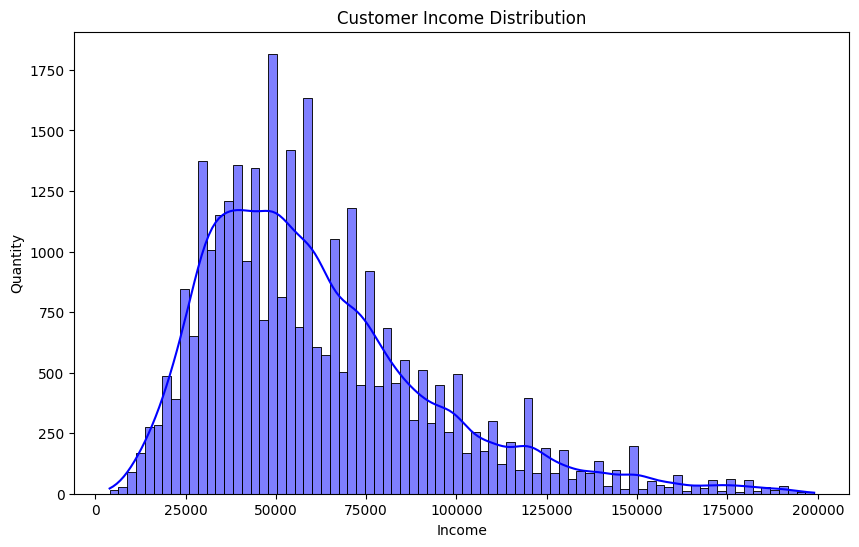

In [8]:
plt.figure(figsize = (10,6))
sns.histplot(df[df['person_income'] < 200000]['person_income'], kde = True, color = 'blue')
plt.title('Customer Income Distribution')
plt.xlabel('Income')
plt.ylabel('Quantity')
plt.show()

In [9]:
df['total_debt'] = df['loan_amnt'] + df['other_debt']

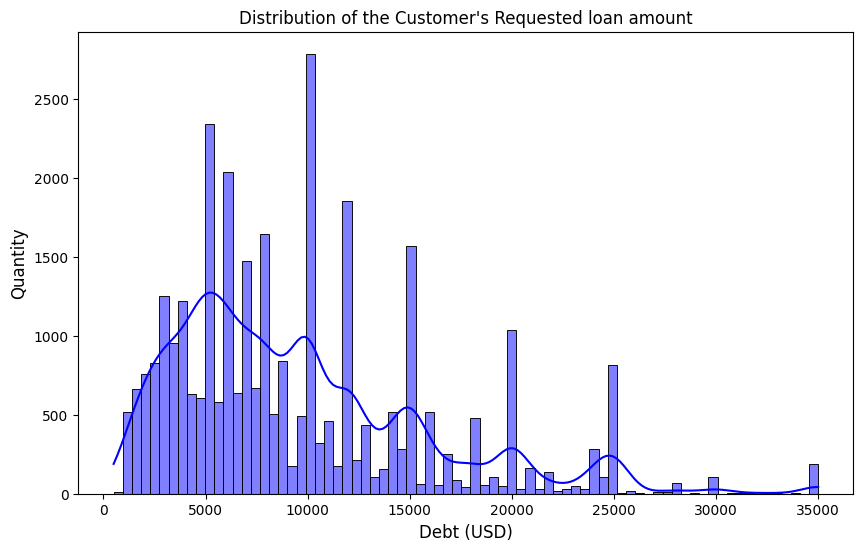

In [10]:
plt.figure(figsize = (10,6))
sns.histplot(df['loan_amnt'], kde=True, color='blue')

plt.title("Distribution of the Customer's Requested loan amount")
plt.xlabel('Debt (USD)', fontsize=12)
plt.ylabel('Quantity', fontsize=12)

plt.show()

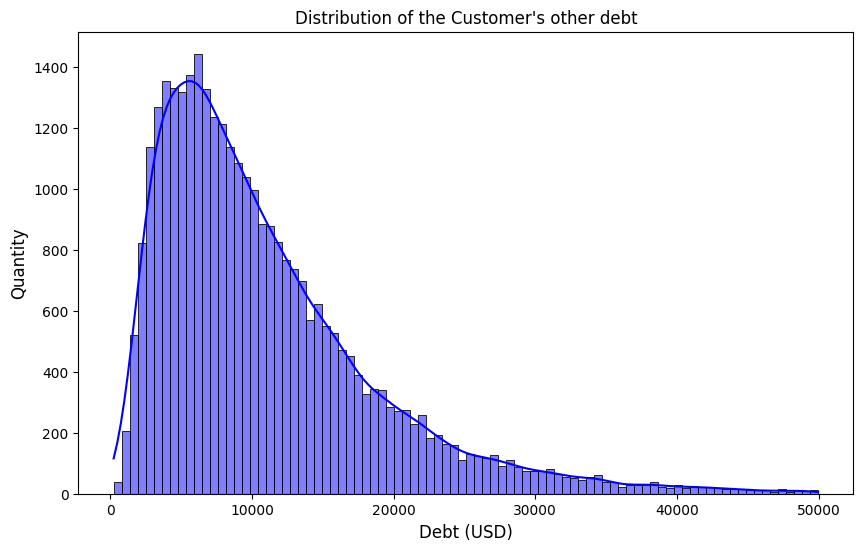

In [11]:
plt.figure(figsize = (10,6))
sns.histplot(df[df['other_debt'] < 50000]['other_debt'], kde=True, color='blue')

plt.title("Distribution of the Customer's other debt")
plt.xlabel('Debt (USD)', fontsize=12)
plt.ylabel('Quantity', fontsize=12)

plt.show()

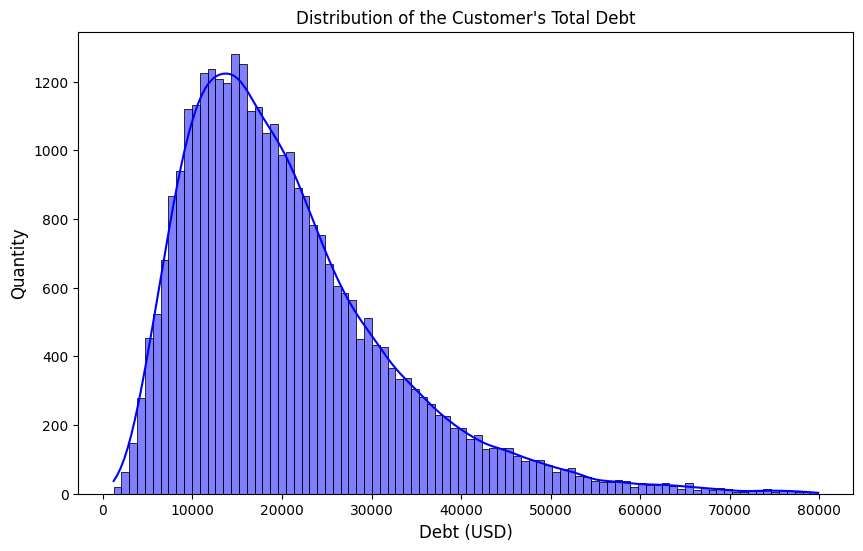

In [12]:
plt.figure(figsize = (10,6))
sns.histplot(df[df['total_debt'] < 80000]['total_debt'], kde=True, color='blue')

plt.title("Distribution of the Customer's Total Debt")
plt.xlabel('Debt (USD)', fontsize=12)
plt.ylabel('Quantity', fontsize=12)

plt.show()

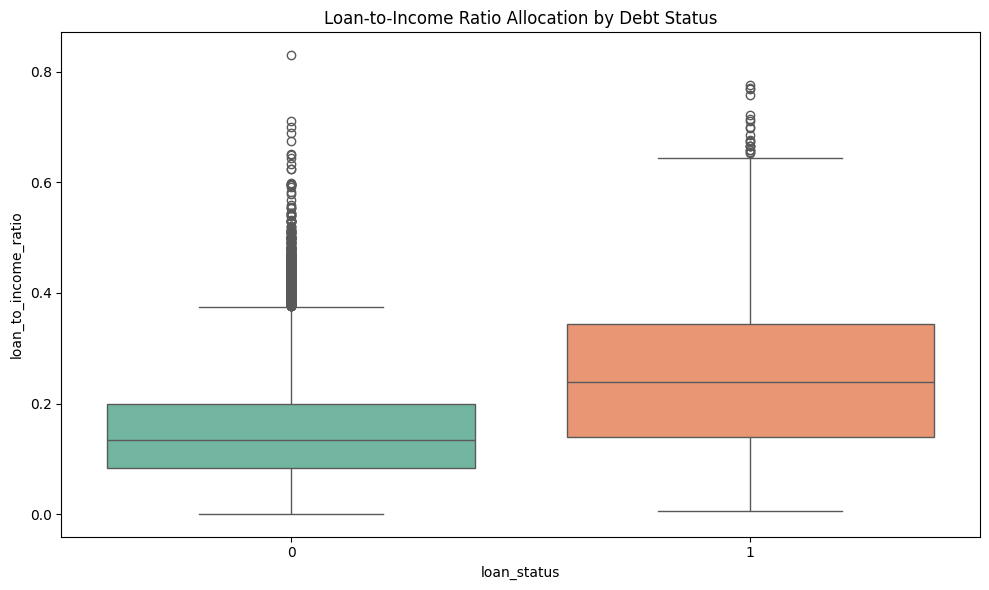

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data = df,
    x = 'loan_status',
    y = 'loan_to_income_ratio',
    palette = 'Set2',
    hue = 'loan_status',
    legend=False
)

plt.title("Loan-to-Income Ratio Allocation by Debt Status")
plt.tight_layout()
plt.show()

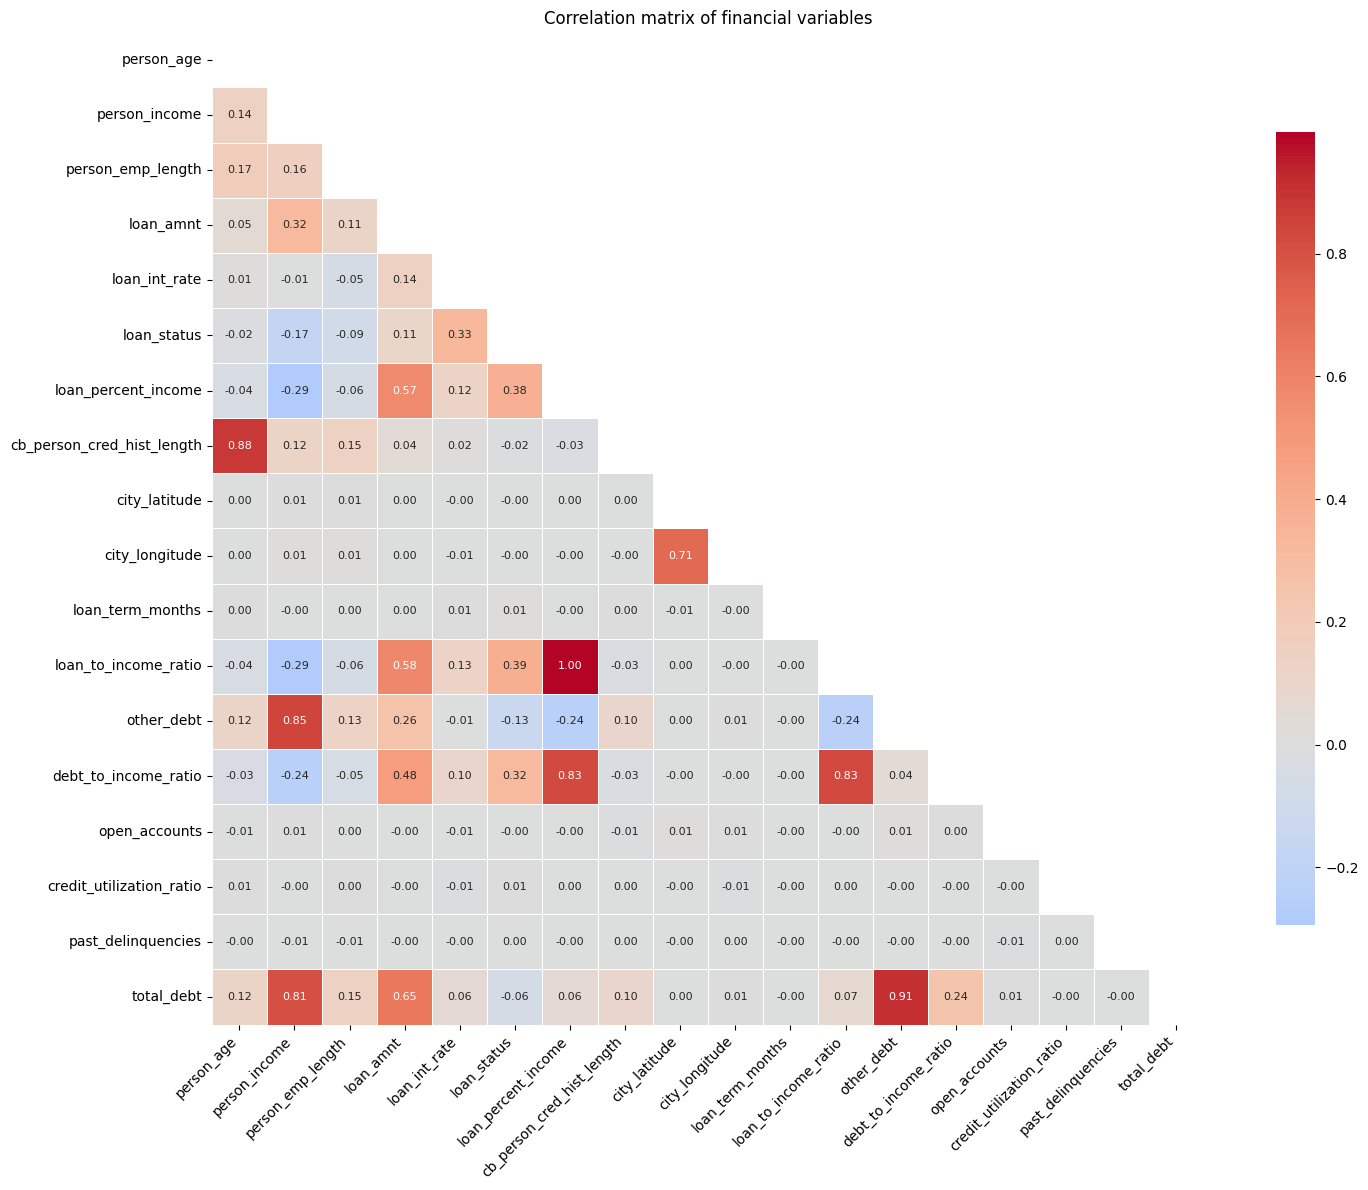

In [14]:
numeric_df = df.select_dtypes(include=[np.number])

if 'client_ID' in numeric_df.columns : 
    numeric_df = numeric_df.drop(columns = ['client_ID'])

corr_matrix = numeric_df.corr()

plt.figure(figsize= (16,12))

mask = np.triu(np.ones_like(corr_matrix, dtype = bool))

heatmap = sns.heatmap(
    corr_matrix,
    mask = mask,
    annot = True,
    fmt = ".2f",
    cmap = 'coolwarm',
    center = 0,
    square = True,
    linewidths= .5,
    cbar_kws={"shrink": .8},
    annot_kws={"size": 8}
)

plt.title("Correlation matrix of financial variables")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

C:\Users\embes\AppData\Local\Temp\ipykernel_7656\433261393.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(x=correlations.values, y=correlations.index, palette=colors)


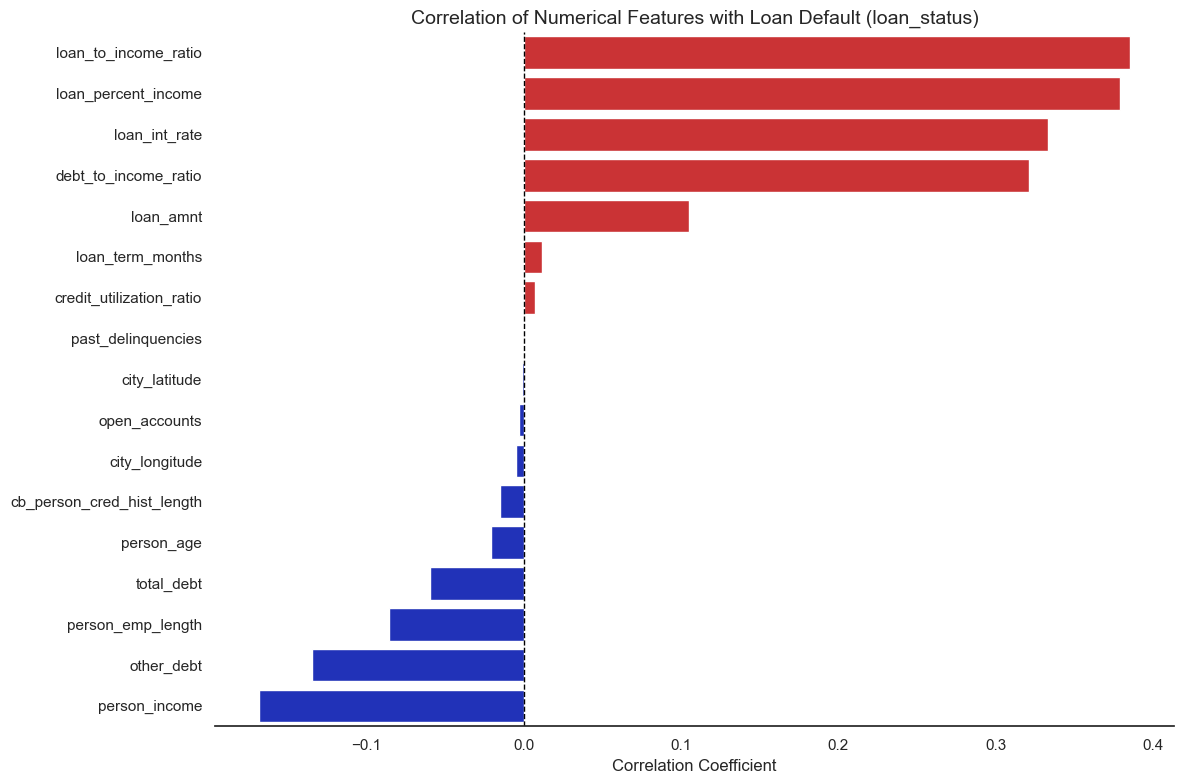

In [15]:
numerical_df = df.select_dtypes(include=[np.number])
correlations = numerical_df.corr()['loan_status'].sort_values(ascending=False).drop('loan_status')

plt.figure(figsize=(12, 8))
sns.set_theme(style="white")

colors = ['#e31a1c' if x > 0 else '#081fd1' for x in correlations.values]

plot = sns.barplot(x=correlations.values, y=correlations.index, palette=colors)

plt.title('Correlation of Numerical Features with Loan Default (loan_status)', fontsize=14)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('', fontsize=12) # Để trống nhãn Y vì tên biến đã rõ ràng

plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

sns.despine(left=True, bottom=False)

plt.tight_layout()
plt.show()

In [16]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'client_ID' in categorical_cols:
    categorical_cols.remove('client_ID')

def perform_test(data, col, target='loan_status'):
    contingency_table = pd.crosstab(data[col], data[target])
    
    # Thực hiện kiểm định Chi-Square
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    # Tính toán Cramer's V
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    cramers_v = np.sqrt(chi2 / (n * (min(k, r) - 1)))
    
    return p, cramers_v

results = []
for col in categorical_cols:
    p_val, v_val = perform_test(df, col)
        
    results.append({
        'Cột dữ liệu': col,
        'P-value': p_val,
        'Cramer\'s V': v_val,
    })

analysis_results = pd.DataFrame(results).sort_values(by='Cramer\'s V', ascending=False)
print("--- KẾT QUẢ KIỂM ĐỊNH CHI-SQUARE & CRAMER'S V ---")
print(analysis_results.to_string(index=False))

--- KẾT QUẢ KIỂM ĐỊNH CHI-SQUARE & CRAMER'S V ---
              Cột dữ liệu       P-value  Cramer's V
               loan_grade  0.000000e+00    0.414837
    person_home_ownership  0.000000e+00    0.241983
cb_person_default_on_file 9.953651e-229    0.178904
              loan_intent 3.931963e-110    0.126342
                     city  1.615906e-01    0.026359
                    state  5.266334e-01    0.014756
          employment_type  4.460204e-01    0.009047
          education_level  4.953332e-01    0.008567
           marital_status  9.516273e-01    0.003248
                  country  9.638985e-01    0.001503
                   gender  8.251024e-01    0.001224


In [17]:
# Label Encoding cho loan_grade (thứ tự rủi ro tăng dần)
grade_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6}
df['loan_grade'] = df['loan_grade'].map(grade_map)

# Label Encoding cho cb_person_default_on_file
df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map({'N': 0, 'Y': 1})

# One-Hot Encoding cho các biến còn lại
df = pd.get_dummies(df, columns=['person_home_ownership', 'loan_intent'], prefix=['home', 'intent'])

# Chuyển các cột True/False thành 0/1 để mô hình dễ đọc hơn
for col in df.columns:
    if df[col].dtype == 'bool':
        df[col] = df[col].astype(int)


In [18]:
y = df['loan_status']
# Chuyển đổi TẤT CẢ các biến phân loại thành dạng số

X = df.drop(columns=['loan_status', 'client_ID', 'country', 'state', 'city'])
X = pd.get_dummies(X, drop_first=True)

# Huấn luyện mô hình 
print("Đang huấn luyện mô hình với toàn bộ biến...")
model = xgb.XGBClassifier(n_estimators=100, max_depth=4, random_state=42)
model.fit(X, y)

# SHAP Interaction Values
print("Đang tính toán ma trận tương tác...")
explainer = shap.TreeExplainer(model)
shap_interaction_values = explainer.shap_interaction_values(X)

# Lọc và Hiển thị
mean_interaction_matrix = np.abs(shap_interaction_values).mean(axis=0)
interaction_df = pd.DataFrame(mean_interaction_matrix, index=X.columns, columns=X.columns)

np.fill_diagonal(interaction_df.values, 0) # Xóa đường chéo để nhìn rõ tương tác chéo

# Top cặp tương tác mạnh nhất
top_interactions = interaction_df.unstack().sort_values(ascending=False).drop_duplicates()
print("\nTop 20 cặp biến tương tác mạnh nhất (Hãy xem có biến nào bạn định xóa nằm ở đây không!):")
print(top_interactions.head(20))

Đang huấn luyện mô hình với toàn bộ biến...
Đang tính toán ma trận tương tác...

Top 20 cặp biến tương tác mạnh nhất (Hãy xem có biến nào bạn định xóa nằm ở đây không!):
loan_to_income_ratio  loan_percent_income         0.418146
loan_percent_income   loan_to_income_ratio        0.418146
home_RENT             loan_to_income_ratio        0.168351
person_emp_length     loan_grade                  0.103126
loan_grade            person_emp_length           0.103126
                      intent_DEBTCONSOLIDATION    0.093610
                      intent_VENTURE              0.089762
intent_VENTURE        loan_grade                  0.089762
intent_MEDICAL        loan_grade                  0.076135
loan_grade            intent_MEDICAL              0.076135
loan_to_income_ratio  loan_grade                  0.066430
loan_grade            loan_to_income_ratio        0.066430
loan_to_income_ratio  home_MORTGAGE               0.065583
home_MORTGAGE         loan_to_income_ratio        0.065583
loan

In [ ]:
cols_to_drop = [
    'employment_type', 
    'education_level', 
    'marital_status', 
    'country', 
    'gender',
    'city',
    'state',
    'past_delinquencies',
    'city_latitude',
    'city_longitude',
    'credit_utilization_ratio',
    'open_accounts',
    'client_ID' 
]

df_final = df.drop(columns=cols_to_drop)

print("Các cột còn lại trong bộ dữ liệu:")
print(df_final.columns.tolist())

df_final.to_csv('CleanData.csv', index=False, encoding="utf-8-sig")

Các cột còn lại trong bộ dữ liệu:
['person_age', 'person_income', 'person_emp_length', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'loan_term_months', 'loan_to_income_ratio', 'other_debt', 'debt_to_income_ratio', 'total_debt', 'home_MORTGAGE', 'home_OTHER', 'home_OWN', 'home_RENT', 'intent_DEBTCONSOLIDATION', 'intent_EDUCATION', 'intent_HOMEIMPROVEMENT', 'intent_MEDICAL', 'intent_PERSONAL', 'intent_VENTURE']
